In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import seaborn as sns
import os, sys

sys.path.insert(0, os.path.abspath('..'))

from src.constants import (N_COMPONENTS_PCA, N_COMPONENTS_PLS, REDUCTION_METHOD, ASSET_COLS, 
                           COLOR_EXP as COLOR_0, COLOR_REC as COLOR_1, SHADE_COL, SHADE_A, LW)
from src.data_loader import load_macro_data, load_asset_data
from src.preprocess import prepare_macro_data, apply_dim_reduction, loading_table, train_test_split
from src.msvar_model import MSVARRegimeModel
from src.portfolio import (estimate_regime_moments, shrinkage_diagnostics,
                            optimize_regimes)
from src.plots import (plot_regime_states, plot_regime_probs, plot_regime_nber)


## Description

This notebook implements regime detection using **MSMH-VAR(K=2, p=1)** — a Markov-Switching Mean-Heteroskedastic Vector Autoregression.  Conditional on state k, macro indicators follow a VAR(1) process rather than being i.i.d. draws as in the Gaussian HMM.

The estimation pipeline is:
- **E-step**: Hamilton filter (forward pass) + Kim smoother (backward pass)
- **M-step**: Weighted OLS for VAR coefficients and covariances; MLE for the transition matrix

The MSVAR captures autoregressive macro dynamics that the HMM misses, and tends to produce more stable, less noisy regime classifications.

## Data preparation

Robust-scale macro indicators, apply PCA, and winsorize extreme scores.
VAR(p=1) consumes the first observation as a lag, so the effective sample size is T - 1 and regime labels align to `dates_train[1:]`.

In [2]:
macro_df = load_macro_data("../data/macro_clean.csv")
macro_df.head()

,industrial_production,real_person_income,unemployment_rate,initial_jobless_claims,continuing_claims,cpi,oil_price,vix,credit_spread,yield_curve_slope,fed_funds_rate,consumer_sentiment,housing_starts,m2_money_supply,dollar_index
Date,,,,,,,,,,,,,,,
1990-02-28,0.766740,0.213257,-0.176815,0.086523,0.140235,0.648227,-0.517277,0.338459,-0.860618,-1.015353,0.112648,-0.816259,-0.971936,-0.116878,0.017130
1990-03-31,0.370899,-0.142952,-0.176815,-0.056857,0.082572,0.933078,-0.577370,0.033559,-1.001067,-1.092009,0.277788,0.453545,-1.385261,-0.207448,1.046560
1990-04-30,-0.367268,0.582737,0.366229,0.272514,0.167186,0.056672,-0.934117,0.005227,-1.113426,-1.015353,-0.052492,0.645214,-0.409511,-0.174649,-0.009542
1990-05-31,0.183034,-0.438133,0.004200,-0.054564,0.122786,-0.234552,-0.572546,-0.284832,-0.818483,-0.993451,-0.382773,-0.768342,-0.370488,-0.904505,-0.734113
1990-06-30,0.216958,-0.097920,-0.357829,0.083436,0.050709,1.493735,-0.255118,-0.537116,-0.706123,-0.894894,0.663116,-0.528756,-0.370905,-0.083910,-0.013835


In [3]:
macro_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 431 entries, 1990-02-28 to 2025-12-31
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   industrial_production   431 non-null    float64
 1   real_person_income      431 non-null    float64
 2   unemployment_rate       431 non-null    float64
 3   initial_jobless_claims  431 non-null    float64
 4   continuing_claims       431 non-null    float64
 5   cpi                     431 non-null    float64
 6   oil_price               431 non-null    float64
 7   vix                     431 non-null    float64
 8   credit_spread           431 non-null    float64
 9   yield_curve_slope       431 non-null    float64
 10  fed_funds_rate          431 non-null    float64
 11  consumer_sentiment      431 non-null    float64
 12  housing_starts          431 non-null    float64
 13  m2_money_supply         431 non-null    float64
 14  dollar_index            431 non-nu


── PCA summary ──
  Input dimensions  : 15
  Components kept   : 6  (threshold = 85%)
  Variance explained: 85.0%

  Per-component breakdown:
    PC1: 44.9%  cumulative 44.9%  █████████████████
    PC2: 22.0%  cumulative 66.9%  ████████
    PC3:  6.4%  cumulative 73.3%  ██
    PC4:  5.1%  cumulative 78.4%  ██
    PC5:  3.7%  cumulative 82.1%  █
    PC6:  3.0%  cumulative 85.0%  █

  Projected train shape : (431, 6)


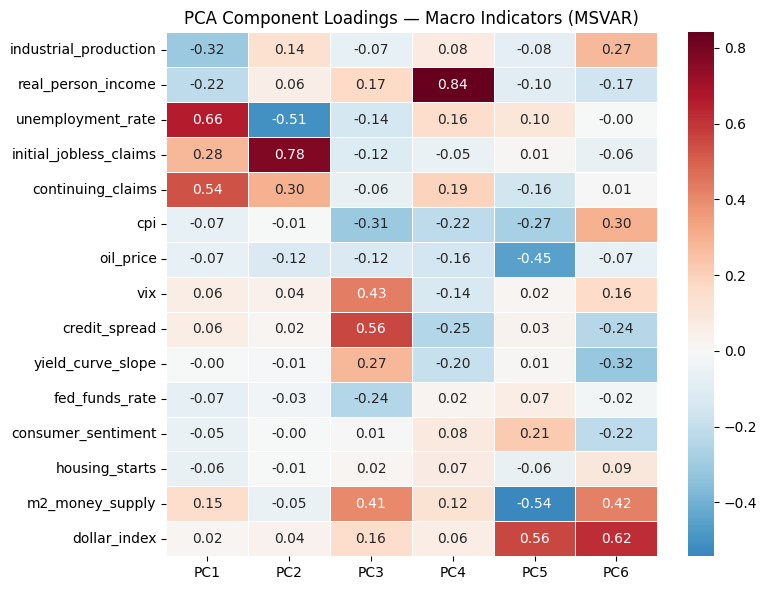

,PC1,PC2,PC3,PC4,PC5,PC6
industrial_production,-0.315169,0.136588,-0.069248,0.075304,-0.082776,0.272948
real_person_income,-0.215720,0.055688,0.167748,0.841148,-0.097194,-0.169222
unemployment_rate,0.658866,-0.507020,-0.143152,0.159169,0.101060,-0.000479
initial_jobless_claims,0.283134,0.780911,-0.115395,-0.052534,0.011924,-0.057655
continuing_claims,0.535383,0.298170,-0.057772,0.194646,-0.158969,0.007309
cpi,-0.068211,-0.006901,-0.306884,-0.222067,-0.274867,0.295939
oil_price,-0.070292,-0.120084,-0.123049,-0.156983,-0.453607,-0.069949
vix,0.063464,0.044684,0.427994,-0.135428,0.017409,0.164414
credit_spread,0.063300,0.017236,0.559525,-0.245439,0.026473,-0.237367
yield_curve_slope,-0.002262,-0.011050,0.274523,-0.195525,0.010903,-0.318792


In [4]:
X_train, X_test, scaler, dates_train, dates_test = prepare_macro_data(macro_df)
# Select appropriate number of principal components based on reduction method
if REDUCTION_METHOD == 'pca':
    N_COMPONENTS = N_COMPONENTS_PCA
elif REDUCTION_METHOD == 'pls':
    N_COMPONENTS = N_COMPONENTS_PLS
else:
    N_COMPONENTS = None
# Fitted on training data, clips applied
X_train_reduced, X_test_reduced, reducer = apply_dim_reduction(X_train, X_test,
                                          n_components=N_COMPONENTS, 
                                          method=REDUCTION_METHOD)


# loadings heatmap
loadings = loading_table(reducer, macro_df.columns.tolist())
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5)
plt.title('PCA Component Loadings — Macro Indicators (MSVAR)')
plt.tight_layout()
plt.savefig(f'../outputs/figures/{REDUCTION_METHOD}_loadings_msvar.png', dpi=150,
            bbox_inches='tight')
plt.show()
display(loadings)


Note that the proportion of variance explained is greater than the value from the dimensionality reduction notebook because the reduction method here is only fitted on the training data (whereas it is fitted to the whole data sample in the other notebook).

In [5]:
print('Raw scaled  :', X_train.shape, X_test.shape if X_test is not None else None)
print('PCA reduced :', X_train_reduced.shape, X_test_reduced.shape if X_test_reduced is not None else None)


Raw scaled  : (431, 15) None
PCA reduced : (431, 6) None


## Model fitting

Fit MSMH-VAR(K=2, p=1) via EM with multiple random restarts.  The best restart (highest log-likelihood) is retained.  State ordering is enforced automatically: state 0 = expansion, state 1 = recession.

In [6]:
# Feed PCA-projected winsorized data to the MSVAR.
# Regime labels (integers indexed by date) are attached back to
# macro_df_expanded after fitting — all visualization cells unchanged.
model = MSVARRegimeModel(
    n_states=2, p=1, n_restarts=5, max_iter=300,
    tol=1e-6, random_state=42, verbose=True
)
model.fit(X_train_reduced)



--- Restart 1/5 ---
  iter    0 | log-lik = -1111.618039 | Δ = inf
  iter   10 | log-lik = -845.532218 | Δ = 3.83e+01
  iter   20 | log-lik = -701.419512 | Δ = 3.14e-01
  iter   30 | log-lik = -700.621311 | Δ = 1.96e-04
  Converged at iteration 39.

--- Restart 2/5 ---
  iter    0 | log-lik = -1141.757207 | Δ = inf
  iter   10 | log-lik = -702.513979 | Δ = 3.84e-01
  iter   20 | log-lik = -700.624927 | Δ = 6.20e-03
  iter   30 | log-lik = -700.621145 | Δ = 2.96e-06
  Converged at iteration 33.

--- Restart 3/5 ---
  iter    0 | log-lik = -1108.698072 | Δ = inf
  iter   10 | log-lik = -888.069636 | Δ = 3.17e+01
  iter   20 | log-lik = -701.775506 | Δ = 3.71e-01
  iter   30 | log-lik = -700.621537 | Δ = 5.30e-04
  iter   40 | log-lik = -700.621141 | Δ = 9.36e-07
  Converged at iteration 40.

--- Restart 4/5 ---
  iter    0 | log-lik = -1149.114085 | Δ = inf
  iter   10 | log-lik = -839.679879 | Δ = 8.41e+01
  iter   20 | log-lik = -751.617852 | Δ = 1.54e-03
  Converged at iteration 29.


In [7]:
model.summary()

MSMH-VAR(2, 1)  |  n=6, T=430
Log-likelihood : -700.6211
AIC            : 1657.2423
BIC            : 2177.4068
# parameters   : 128
EM iterations  : 34

Transition Matrix P (row i -> col j):
[[0.969  0.031 ]
 [0.2358 0.7642]]

Expected Regime Durations (periods):
  Regime 0: 32.2
  Regime 1: 4.2

Effective Sample Sizes:
  Regime 0: 380.1 obs (88.4%)
  Regime 1: 49.9 obs (11.6%)

--- Regime 0 VAR Intercept (mu) ---
[-0.045996 -0.004263  0.006237  0.010357  0.005147 -0.007795]
--- Regime 0 Covariance Sigma ---
[[ 0.15066   0.025744 -0.029108 -0.015832  0.016219 -0.010092]
 [ 0.025744  0.082639 -0.00711   0.000782  0.012275 -0.003918]
 [-0.029108 -0.00711   0.063937  0.026671  0.009988  0.017103]
 [-0.015832  0.000782  0.026671  0.065119  0.01397  -0.001611]
 [ 0.016219  0.012275  0.009988  0.01397   0.106481  0.007603]
 [-0.010092 -0.003918  0.017103 -0.001611  0.007603  0.070724]]

--- Regime 1 VAR Intercept (mu) ---
[ 0.020156 -0.172868  0.019733 -0.159409 -0.117861 -0.01581 ]
--- Regi

## Extracting results

In [8]:
# State 0 = expansion, state 1 = recession — enforced by _sort_regimes().
# No manual label flip needed (unlike original notebook).
smoothed_probs_train = model.smoothed_probs()
print('Smoothed probs shape:', smoothed_probs_train.shape)
print('Sum to 1:', np.allclose(smoothed_probs_train.sum(axis=0), 1.0))


Smoothed probs shape: (2, 430)
Sum to 1: True


In [9]:
# Filtered probs use only information up to time t — correct for
# walk-forward / out-of-sample evaluation (no look-ahead bias).
filtered_probs_train = model.filtered_probs()
print('Filtered probs shape:', filtered_probs_train.shape)
print('Sum to 1:', np.allclose(filtered_probs_train.sum(axis=0), 1.0))


Filtered probs shape: (2, 430)
Sum to 1: True


In [10]:
states_sequence = model.predict(use_smoothed=True)
print('State counts:', np.unique(states_sequence, return_counts=True))


State counts: (array([0, 1]), array([384,  46]))


In [11]:
# VAR(p=1) drops the first observation as a lag — align to dates_train[1:]
dates_msvar = dates_train[model.p:]
states_sequence_series = pd.Series(
    states_sequence, index=dates_msvar, name='MSVAR State'
)
states_sequence_series.value_counts()


MSVAR State
0    384
1     46
Name: count, dtype: int64

### Transition matrix

In [12]:
pd.DataFrame(
    model.transmat_,
    columns=[f'State {i}' for i in range(model.n_components)],
    index=[f'State {i}'   for i in range(model.n_components)]
)


,State 0,State 1
State 0,0.968989,0.031011
State 1,0.235838,0.764162


In [13]:
print('Average duration in each state (expected consecutive months):')
for i, d in enumerate(model.expected_durations):
    label = 'Expansion' if i == 0 else 'Recession'
    print(f'  State {i} ({label}): {d:.2f} months')


Average duration in each state (expected consecutive months):
  State 0 (Expansion): 32.25 months
  State 1 (Recession): 4.24 months


### Conditional means and covariance matrices

After PCA, `model.means_` has shape (K, n_components) representing the VAR intercept vector per regime in PC space.  Cross-reference with the loadings table above to interpret in original variable space.

In [14]:
if hasattr(reducer, 'n_components_'):   # PCA
    n_comp = reducer.n_components_
    component_names = [f'PC{j+1}'  for j in range(n_comp)]
else:                                    # PLS
    n_comp = reducer.n_components
    component_names = [f'PLS{j+1}' for j in range(n_comp)]

pd.DataFrame(
    model.means_,
    columns=component_names,
    index=['State 0', 'State 1']
).T


,State 0,State 1
PC1,-0.045996,0.020156
PC2,-0.004263,-0.172868
PC3,0.006237,0.019733
PC4,0.010357,-0.159409
PC5,0.005147,-0.117861
PC6,-0.007795,-0.015810


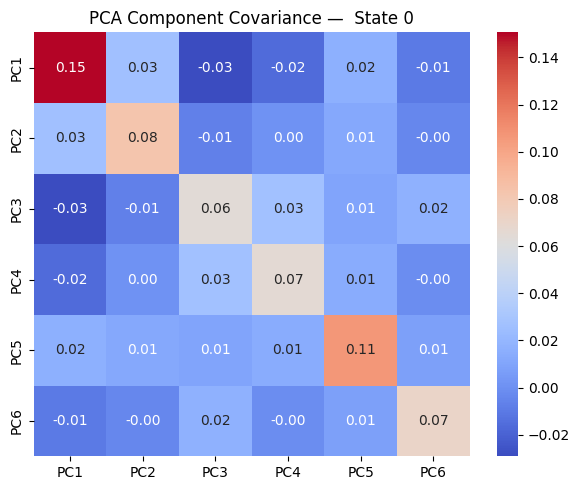

In [15]:
plt.figure(figsize=(6, 5))
sns.heatmap(model.covars_[0], annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=component_names, yticklabels=component_names)
plt.title('PCA Component Covariance —  State 0')
plt.tight_layout()
plt.show()


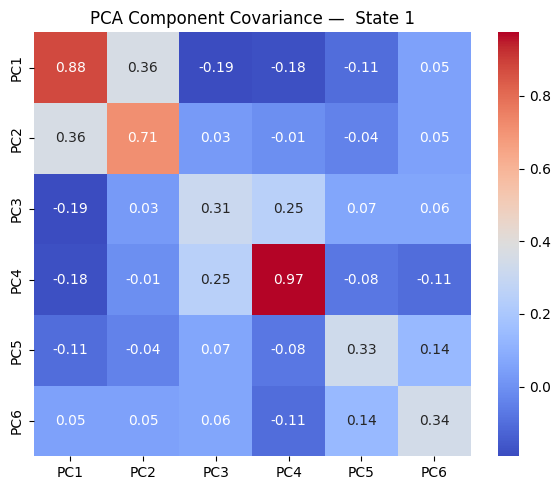

In [16]:
plt.figure(figsize=(6, 5))
sns.heatmap(model.covars_[1], annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=component_names, yticklabels=component_names)
plt.title('PCA Component Covariance —  State 1')
plt.tight_layout()
plt.show()


## Plotting results

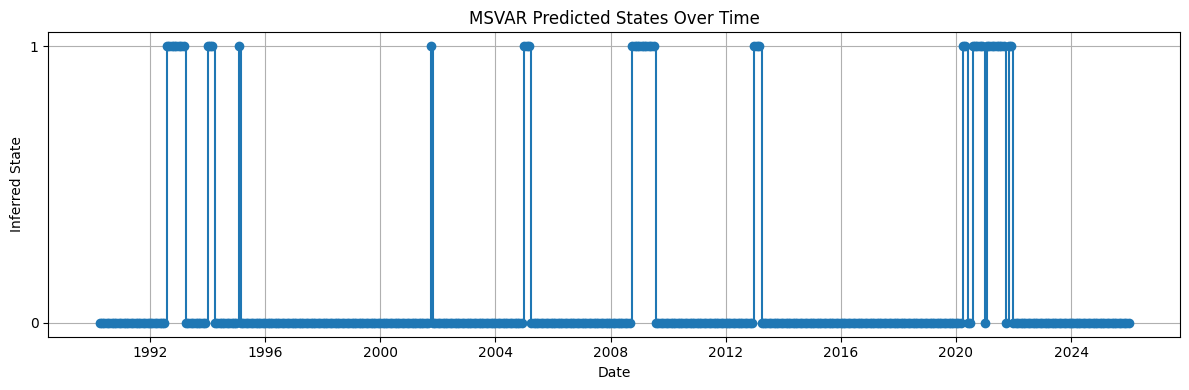

In [17]:
plot_regime_states(dates_msvar, states_sequence,
                   title='MSVAR Predicted States Over Time')
plt.show()


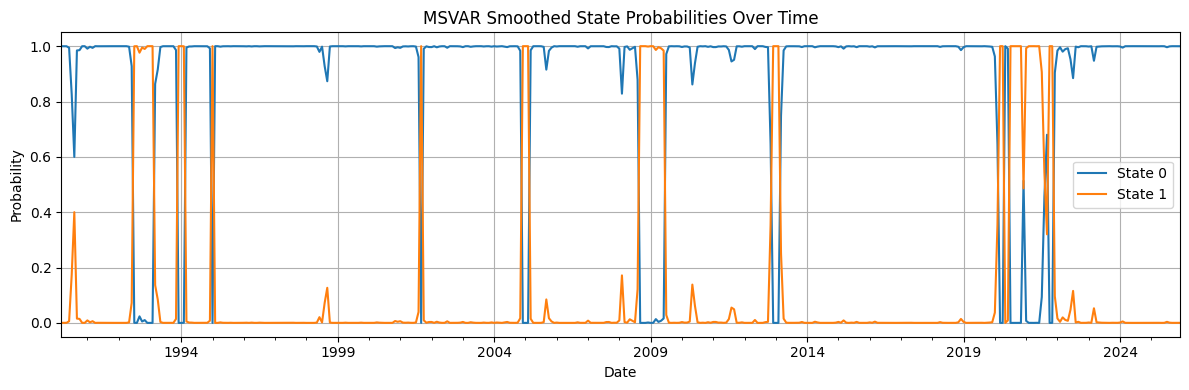

In [18]:
plot_regime_probs(dates_msvar, smoothed_probs_train,
                  title='MSVAR Smoothed State Probabilities Over Time')
plt.show()


In [19]:
# Attach regime labels to the original macro_df (original variable names).
# All downstream visualization cells use original series — PCA is invisible.
macro_df_expanded = macro_df.loc[dates_msvar].copy()
macro_df_expanded['MSVAR State'] = states_sequence


In [20]:
asset_df = load_asset_data('../data/market_clean.csv')
asset_df.columns = ['Equity', 'Bonds', 'Gold']
asset_df_expanded = asset_df.loc[dates_msvar].copy()
asset_df_expanded['MSVAR State'] = macro_df_expanded['MSVAR State']


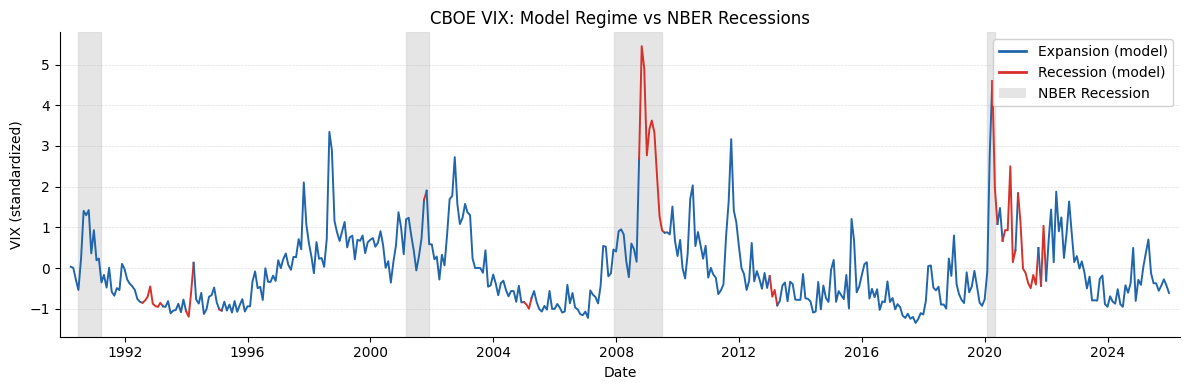

In [21]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_regime_nber(
    macro_df_expanded, series_name='vix', state_col='MSVAR State',
    recession_state=1,
    title='CBOE VIX: Model Regime vs NBER Recessions',
    ylabel='VIX (standardized)', ax=ax
)
plt.tight_layout()
plt.show()

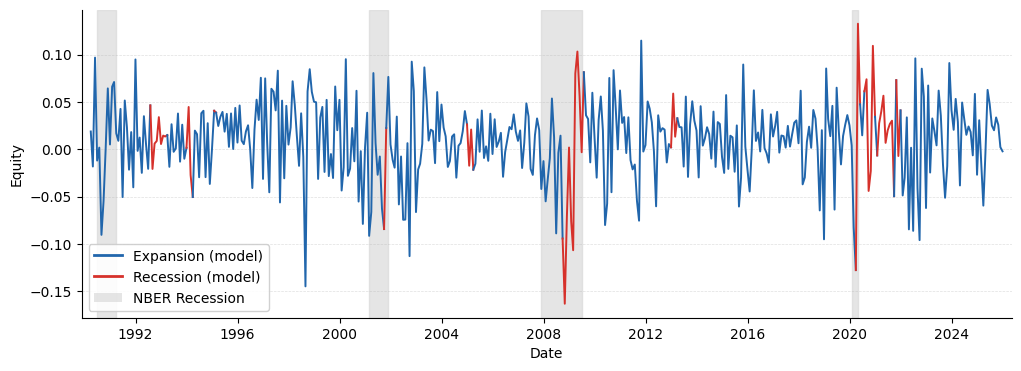

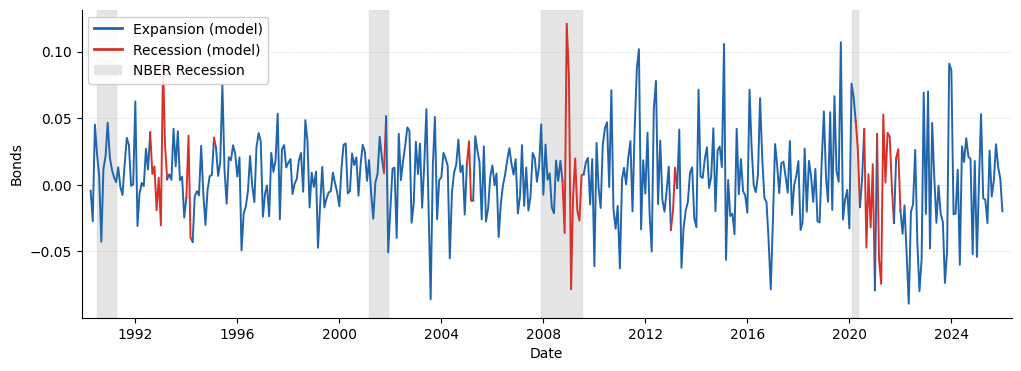

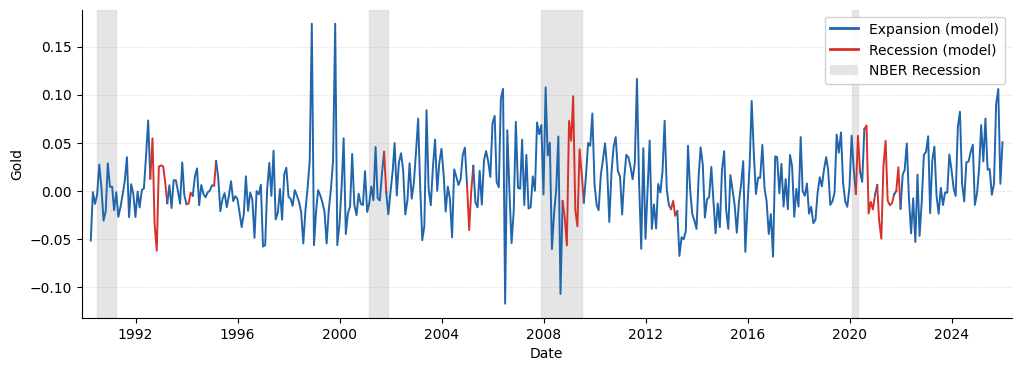

In [22]:
for col in asset_df.columns:
    plot_regime_nber(asset_df_expanded, series_name=col,
                       state_col='MSVAR State', recession_state=1)
    plt.show()


## Portfolio optimization

Regime-conditional MVO using Ledoit-Wolf covariance shrinkage and Bayes-Stein mean shrinkage, estimated on the training set.

In [23]:
market_train, market_test = train_test_split(asset_df_expanded)
print('Last train date:', market_train.index[-1])
print('First test date:', market_test.index[0])


Last train date: 2018-10-31 00:00:00
First test date: 2018-11-30 00:00:00


In [24]:
moments = estimate_regime_moments(
    market_train,
    asset_cols=market_train.columns[:-1].tolist(),
    state_col='MSVAR State'
)



── Regime 0  (315 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    Equity          : sample +11.67%  →  BS +10.45%
    Bonds           : sample +7.34%  →  BS +7.52%
    Gold            : sample +4.82%  →  BS +4.81%
  Bayes-Stein φ  : 0.9529  (heavy shrinkage)
  Ledoit-Wolf α  : 0.1804
  Implied annual volatilities (shrunk Σ):
    Equity          : 13.26%
    Bonds           : 10.03%
    Gold            : 12.50%

── Regime 1  (29 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    Equity          : sample -3.50%  →  BS +6.81%
    Bonds           : sample +9.50%  →  BS +8.04%
    Gold            : sample +4.75%  →  BS +4.80%
  Bayes-Stein φ  : 0.7421  (heavy shrinkage)
  Ledoit-Wolf α  : 0.8900
  Implied annual volatilities (shrunk Σ):
    Equity          : 16.60%
    Bonds           : 15.90%
    Gold            : 15.78%


In [25]:
shrinkage_diagnostics(moments, asset_cols=market_train.columns[:-1].tolist())



── Ledoit-Wolf shrinkage effect (shrunk Σ − raw Σ) ──

Regime 0  (α = 0.1804):
          Equity   Bonds    Gold
  Equity-0.00006 0.00003 0.00002
   Bonds 0.00003 0.00008-0.00003
    Gold 0.00002-0.00003-0.00003

Regime 1  (α = 0.8900):
          Equity   Bonds    Gold
  Equity-0.00123-0.00026 0.00035
   Bonds-0.00026 0.00037 0.00011
    Gold 0.00035 0.00011 0.00063


In [26]:
asset_names = market_train.columns[:-1]

print('=' * 55)
print('Regime-Conditional MVO')
print('=' * 55)
results = optimize_regimes(moments, asset_names, rf=0.0, long_only=True)


Regime-Conditional MVO

── min_variance  |  Regime 0 ──
  Expected return (ann.) : +7.73%
  Volatility     (ann.) : 6.65%
  Sharpe ratio          : 1.1624
  Weights:
    Equity        : 0.3068  (30.7%)
    Bonds         : 0.4387  (43.9%)
    Gold          : 0.2545  (25.4%)

── max_sharpe  |  Regime 0 ──
  Expected return (ann.) : +8.25%
  Volatility     (ann.) : 6.87%
  Sharpe ratio          : 1.2010
  Weights:
    Equity        : 0.3899  (39.0%)
    Bonds         : 0.4584  (45.8%)
    Gold          : 0.1517  (15.2%)

── min_variance  |  Regime 1 ──
  Expected return (ann.) : +6.51%
  Volatility     (ann.) : 9.25%
  Sharpe ratio          : 0.7043
  Weights:
    Equity        : 0.3123  (31.2%)
    Bonds         : 0.3359  (33.6%)
    Gold          : 0.3519  (35.2%)

── max_sharpe  |  Regime 1 ──
  Expected return (ann.) : +6.79%
  Volatility     (ann.) : 9.44%
  Sharpe ratio          : 0.7192
  Weights:
    Equity        : 0.3236  (32.4%)
    Bonds         : 0.4143  (41.4%)
    Gold     

The recession regime has far fewer observations (~15-20 months vs ~150+ for expansion). Bayes-Stein shrinkage pulls the recession-regime mean toward the grand mean, making the MVO weights more conservative and less sensitive to noisy estimates.

### Target weights export

In [27]:
# ── Consolidated weight export: GMV and MVO ──────────────────────────
# Both exported for comparison in notebook 05.
# MVO weights come from results[k]['max_sharpe'] — already computed
# by optimize_regimes(); no need for a separate MeanVariancePortfolio call.
output_path = os.path.join('..', 'outputs/tables')
os.makedirs(output_path, exist_ok=True)

for label, obj in [('gmv', 'min_variance'), ('mvo', 'max_sharpe')]:
    weights_by_regime = {k: results[k][obj].weights for k in results}
    rows = []
    for date, regime in states_sequence_series.items():
        w = weights_by_regime[regime]
        rows.append({
            'Date':   date,
            'Regime': regime,
            'Equity': w[0],
            'Bonds':  w[1],
            'Gold':   w[2],
        })
    fname = f'msvar_{REDUCTION_METHOD}_{label}_target_weights.csv'
    pd.DataFrame(rows).to_csv(os.path.join(output_path, fname), index=False)
    print(f'Saved {fname}')
    display(pd.DataFrame(rows).head(3))


Saved msvar_pca_gmv_target_weights.csv


,Date,Regime,Equity,Bonds,Gold
0,1990-03-31,0,0.306771,0.438742,0.254487
1,1990-04-30,0,0.306771,0.438742,0.254487
2,1990-05-31,0,0.306771,0.438742,0.254487


Saved msvar_pca_mvo_target_weights.csv


,Date,Regime,Equity,Bonds,Gold
0,1990-03-31,0,0.389901,0.458388,0.151712
1,1990-04-30,0,0.389901,0.458388,0.151712
2,1990-05-31,0,0.389901,0.458388,0.151712


## Robustness Check: K = 3 Regimes

AIC and BIC are used for model comparison (LR test is non-standard under H0: K=2 per Garcia 1998).

In [28]:
# K=3 robustness check also uses PCA-projected data for consistency.
model_k3 = MSVARRegimeModel(
    n_states=3, p=1, n_restarts=3, max_iter=200,
    tol=1e-5, random_state=42, verbose=True
)
model_k3.fit(X_train_reduced)



--- Restart 1/3 ---
  iter    0 | log-lik = -1008.632693 | Δ = inf
  iter   10 | log-lik = -587.344383 | Δ = 6.14e-01
  iter   20 | log-lik = -487.820850 | Δ = 5.77e+00
  iter   30 | log-lik = -480.702579 | Δ = 1.84e-03
  iter   40 | log-lik = -480.698307 | Δ = 8.37e-05
  iter   50 | log-lik = -480.697997 | Δ = 1.18e-05
  Converged at iteration 52.

--- Restart 2/3 ---
  iter    0 | log-lik = -1087.089239 | Δ = inf
  iter   10 | log-lik = -530.328723 | Δ = 9.17e-01
  iter   20 | log-lik = -530.042599 | Δ = 3.21e-04
  iter   30 | log-lik = -530.041485 | Δ = 4.20e-05
  iter   40 | log-lik = -530.041287 | Δ = 9.40e-06
  Converged at iteration 40.

--- Restart 3/3 ---
  iter    0 | log-lik = -1031.098990 | Δ = inf
  iter   10 | log-lik = -639.485247 | Δ = 1.32e-01
  iter   20 | log-lik = -541.926760 | Δ = 5.87e-01
  iter   30 | log-lik = -512.827847 | Δ = 6.96e-01
  iter   40 | log-lik = -510.452453 | Δ = 3.23e-04
  Converged at iteration 43.
Sort method: 'trace'
State 0 = Expansion  (tr(

In [29]:
T = X_train_reduced.shape[0]
ll_k2      = model._result.log_likelihood
n_params_k2 = model._result.n_params
ll_k3      = model_k3._result.log_likelihood
n_params_k3 = model_k3._result.n_params

lr_stat  = 2 * (ll_k3 - ll_k2)
delta_df = n_params_k3 - n_params_k2

summary_k3 = pd.DataFrame({
    'K':               [2, 3],
    'Log-Likelihood':  [ll_k2, ll_k3],
    'N Parameters':    [n_params_k2, n_params_k3],
    'AIC': [-2*ll_k2 + 2*n_params_k2, -2*ll_k3 + 2*n_params_k3],
    'BIC': [-2*ll_k2 + n_params_k2*np.log(T),
            -2*ll_k3 + n_params_k3*np.log(T)],
})

print(f'LR statistic (K=2 vs K=3): {lr_stat:.2f}  (delta_df = {delta_df})')
print('Note: LR p-value non-standard under H0 — use AIC/BIC.')
display(summary_k3)


LR statistic (K=2 vs K=3): 439.85  (delta_df = 67)
Note: LR p-value non-standard under H0 — use AIC/BIC.


,K,Log-Likelihood,N Parameters,AIC,BIC
0,2,-700.621141,128,1657.242282,2177.704117
1,3,-480.697978,195,1351.395956,2144.287033


In [30]:
states_k3 = model_k3.predict(use_smoothed=True)
print('K=3 state counts:', dict(zip(*np.unique(states_k3, return_counts=True))))

# After PCA, B_list[k][:, 0] is the intercept in PC space.
# Display all components and cross-reference with loadings table.
means_k3 = pd.DataFrame(
    {f'State {k}': model_k3._result.B_list[k][:, 0]
     for k in range(model_k3.n_states)},
    index=component_names
)
print('\nK=3 regime intercepts (PC space):')
display(means_k3)



K=3 state counts: {np.int64(0): np.int64(379), np.int64(1): np.int64(29), np.int64(2): np.int64(22)}

K=3 regime intercepts (PC space):


,State 0,State 1,State 2
PC1,-0.020958,0.381740,-0.496976
PC2,0.005731,-0.198692,-0.085823
PC3,0.000670,-0.325892,0.469318
PC4,0.007346,-0.796284,0.549906
PC5,0.016612,-0.064621,-0.388514
PC6,-0.011996,-0.075282,0.141822


In [31]:
summary_k3.to_csv(os.path.join(output_path, 'msvar_k3_model_selection.csv'),
                  index=False)
means_k3.to_csv(os.path.join(output_path, 'msvar_k3_regime_means.csv'))
print('Saved K=3 MSVAR results.')


Saved K=3 MSVAR results.
